Model to predict Cancellation of the hotel booking

Importing libraries

In [155]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

Loading the dataset

In [128]:
df = pd.read_csv("H1.csv")
df.head(20)

,IsCanceled,LeadTime,ArrivalDateYear,ArrivalDateMonth,ArrivalDateWeekNumber,ArrivalDateDayOfMonth,StaysInWeekendNights,StaysInWeekNights,Adults,Children,...,DepositType,Agent,Company,DaysInWaitingList,CustomerType,ADR,RequiredCarParkingSpaces,TotalOfSpecialRequests,ReservationStatus,ReservationStatusDate
0,0,342,2015,July,27,1,0,0,2,0,...,No Deposit,NULL,NULL,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,0,737,2015,July,27,1,0,0,2,0,...,No Deposit,NULL,NULL,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,0,7,2015,July,27,1,0,1,1,0,...,No Deposit,NULL,NULL,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,0,13,2015,July,27,1,0,1,1,0,...,No Deposit,304,NULL,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,0,14,2015,July,27,1,0,2,2,0,...,No Deposit,240,NULL,0,Transient,98.00,0,1,Check-Out,2015-07-03
5,0,14,2015,July,27,1,0,2,2,0,...,No Deposit,240,NULL,0,Transient,98.00,0,1,Check-Out,2015-07-03
6,0,0,2015,July,27,1,0,2,2,0,...,No Deposit,NULL,NULL,0,Transient,107.00,0,0,Check-Out,2015-07-03
7,0,9,2015,July,27,1,0,2,2,0,...,No Deposit,303,NULL,0,Transient,103.00,0,1,Check-Out,2015-07-03
8,1,85,2015,July,27,1,0,3,2,0,...,No Deposit,240,NULL,0,Transient,82.00,0,1,Canceled,2015-05-06
9,1,75,2015,July,27,1,0,3,2,0,...,No Deposit,15,NULL,0,Transient,105.50,0,0,Canceled,2015-04-22


Shape of dataset

In [129]:
df.shape

(40060, 31)

Datatype 

In [130]:
df.dtypes

IsCanceled                       int64
LeadTime                         int64
ArrivalDateYear                  int64
ArrivalDateMonth                object
ArrivalDateWeekNumber            int64
ArrivalDateDayOfMonth            int64
StaysInWeekendNights             int64
StaysInWeekNights                int64
Adults                           int64
Children                         int64
Babies                           int64
Meal                            object
Country                         object
MarketSegment                   object
DistributionChannel             object
IsRepeatedGuest                  int64
PreviousCancellations            int64
PreviousBookingsNotCanceled      int64
ReservedRoomType                object
AssignedRoomType                object
BookingChanges                   int64
DepositType                     object
Agent                           object
Company                         object
DaysInWaitingList                int64
CustomerType             

Total memory usage

In [131]:
df.memory_usage(deep=True).sum()

np.int64(36490343)

Total Duplicated rows

In [132]:
df.duplicated().sum()

np.int64(6092)

In [133]:
df = df.drop_duplicates()

In [134]:
df.duplicated().sum()

np.int64(0)

Checking for missing values

In [135]:
df.isnull().sum()

IsCanceled                       0
LeadTime                         0
ArrivalDateYear                  0
ArrivalDateMonth                 0
ArrivalDateWeekNumber            0
ArrivalDateDayOfMonth            0
StaysInWeekendNights             0
StaysInWeekNights                0
Adults                           0
Children                         0
Babies                           0
Meal                             0
Country                        446
MarketSegment                    0
DistributionChannel              0
IsRepeatedGuest                  0
PreviousCancellations            0
PreviousBookingsNotCanceled      0
ReservedRoomType                 0
AssignedRoomType                 0
BookingChanges                   0
DepositType                      0
Agent                            0
Company                          0
DaysInWaitingList                0
CustomerType                     0
ADR                              0
RequiredCarParkingSpaces         0
TotalOfSpecialReques

In [136]:
df['Country'].fillna('Unknown', inplace=True)

C:\Users\MSII\AppData\Local\Temp\ipykernel_9736\1255347460.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Country'].fillna('Unknown', inplace=True)


In [137]:
df.isnull().sum()

IsCanceled                     0
LeadTime                       0
ArrivalDateYear                0
ArrivalDateMonth               0
ArrivalDateWeekNumber          0
ArrivalDateDayOfMonth          0
StaysInWeekendNights           0
StaysInWeekNights              0
Adults                         0
Children                       0
Babies                         0
Meal                           0
Country                        0
MarketSegment                  0
DistributionChannel            0
IsRepeatedGuest                0
PreviousCancellations          0
PreviousBookingsNotCanceled    0
ReservedRoomType               0
AssignedRoomType               0
BookingChanges                 0
DepositType                    0
Agent                          0
Company                        0
DaysInWaitingList              0
CustomerType                   0
ADR                            0
RequiredCarParkingSpaces       0
TotalOfSpecialRequests         0
ReservationStatus              0
Reservatio

In [138]:
month_map = {
    'January':1, 'February':2, 'March':3, 'April':4,
    'May':5, 'June':6, 'July':7, 'August':8,
    'September':9, 'October':10, 'November':11, 'December':12
}
df['ArrivalDateMonth'] = df['ArrivalDateMonth'].map(month_map)

In [139]:
df.nunique()

IsCanceled                        2
LeadTime                        412
ArrivalDateYear                   3
ArrivalDateMonth                 12
ArrivalDateWeekNumber            53
ArrivalDateDayOfMonth            31
StaysInWeekendNights             16
StaysInWeekNights                31
Adults                           14
Children                          5
Babies                            3
Meal                              5
Country                         126
MarketSegment                     6
DistributionChannel               4
IsRepeatedGuest                   2
PreviousCancellations            11
PreviousBookingsNotCanceled      31
ReservedRoomType                 10
AssignedRoomType                 11
BookingChanges                   15
DepositType                       3
Agent                           186
Company                         236
DaysInWaitingList                44
CustomerType                      4
ADR                            5880
RequiredCarParkingSpaces    

Dropping columns

To prevent data leakage-> ReservationStatus, ReservationStatusDate

Agent and Company have many "NULL" values-> we can safely remove them

AssignedRoomType-> It can change after booking

ArrivalDateWeekNumber-> Month is already being used



In [140]:
df = df.drop(columns=["ReservationStatus", "ReservationStatusDate", "Agent", "Company", "AssignedRoomType", "ArrivalDateWeekNumber"])
df.shape

(33968, 25)

Feature engineering

In [141]:
df["is_peak_season"] = df['ArrivalDateMonth'].isin([6,7,8,12]).astype(int)  

In [142]:
df["Total_guests"] = df['Adults'] + df["Babies"]+ df['Children']

In [143]:
df["isSoloTraveler"] = (df['Total_guests'] == 1).astype(int)

In [144]:
df['HasChildren'] = (df['Children']>0).astype(int)

In [145]:
df['TotalStay'] = (df['StaysInWeekendNights'] - df["StaysInWeekNights"]).astype(int)

In [146]:
df['IsLeadTimeHigh'] = (df['LeadTime']>90).astype(int)

In [147]:
df["HadPreviousCancellaion"] = (df['PreviousCancellations']>0).astype(int)

In [148]:
df['isADRHigh'] = (df['ADR'] >df['ADR'].median()).astype(int)

In [149]:
df = df.drop(columns=['Adults', 'Children', 'Babies'])

Encoding

In [150]:
df =  pd.get_dummies(df, columns =["CustomerType", "DepositType", "DistributionChannel", "Meal", "MarketSegment"],drop_first=True)

In [152]:
df = pd.get_dummies(df, columns=['Country', 'ReservedRoomType'], drop_first=True)

Converting boolean values to integer types

In [151]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [153]:
df.dtypes.value_counts()

bool       134
int64       39
float64      1
Name: count, dtype: int64

MODEL TRAINING

In [166]:
y = df['IsCanceled']              # target (what you want to predict)
X = df.drop(columns=['IsCanceled'])  # features (inputs)

In [168]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [169]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_train_scale = scaler.fit_transform(X_train)
x_test_scale = scaler.transform(X_test)

In [183]:
from sklearn.linear_model import LogisticRegression

reg = LogisticRegression(class_weight="balanced", max_iter=2000)

reg.fit(x_train_scale, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [184]:
pred = reg.predict(x_test_scale)
pred

array([1, 0, 0, ..., 1, 0, 0], shape=(6794,))

In [196]:
y_probability = reg.predict_proba(x_test_scale)[:,-1]

In [197]:
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score, roc_auc_score, roc_curve

recall = recall_score(y_test,pred)
precision = precision_score(y_test,pred)
accuracy = accuracy_score(y_test,pred)
F1Score = f1_score(y_test,pred)
fpr, tpr, thresholds = roc_curve(y_test, y_probability)
auc_score = roc_auc_score(y_test, y_probability)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1Score:", F1Score)
print("AUC Score:", auc_score)


Accuracy: 0.7883426552840742
Precision: 0.5411430887717876
Recall: 0.8135283363802559
F1Score: 0.6499513145082765
AUC Score: 0.8809162953063436


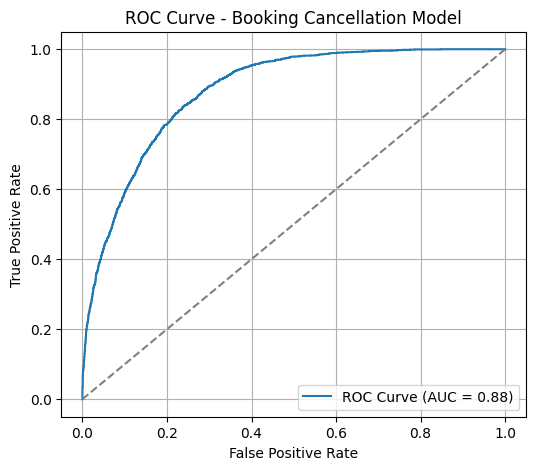

In [200]:
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc_score:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Booking Cancellation Model")
plt.legend()
plt.grid()
plt.show()

In [199]:
import pickle

with open("Hotel-Booking-Cancellation.pkl", "wb") as file:
    pickle.dump(reg, file)